## Tested Algorithms - LightGBM
The model is tested on small subset of the full dataset - "datafile_small.csv". Models are trained on
* Original dataset: using Class Weighting
* SMOTE + RUS Resampling dataset
* RUS Resampling dataset

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import mutual_info_classif 
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix,RocCurveDisplay, classification_report, precision_score, recall_score, f1_score, accuracy_score
from sklearn.pipeline import Pipeline

In [2]:
# PREVIOUS STEPS
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
# IMPORT THE DATASET
data = pd.read_csv('datafile_small.csv',index_col=0)
identity = data.loc[data.index[0:],data.columns[0]].keys() 
#DATA CLEANING STEP - EXPLAINED IN TASK - UNDERSTANDING DATA
data_new = data.drop(columns=['var_45'])
df = data_new.fillna(data_new.median())

In [3]:
# DATA PATRITIONING
random_seed = 100
X = df.drop('target', axis =1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split( 

    X, y, 
    test_size=0.2, 
    random_state=random_seed, 
    stratify=y)

k_list = [180, 120, 60, 30]

In [4]:
# ORIGINAL
X_train_0 = X_train.copy()
y_train_0 = y_train.copy()
print("--- Training set 0: Keeping the original ---") 
print(y_train_0.value_counts())

--- Training set 0: Keeping the original ---
target
0    14429
1     1571
Name: count, dtype: int64



=== LightGBM: Original&Isbalance_LightGBM_top_180 (180 features) ===
[LightGBM] [Info] Number of positive: 1571, number of negative: 14429
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.114100 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 45900
[LightGBM] [Info] Number of data points in the train set: 16000, number of used features: 180
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.098187 -> initscore=-2.217528
[LightGBM] [Info] Start training from score -2.217528
AUC: 0.8473896177280394
Confusion Matrix:
 [[3522   85]
 [ 268  125]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95      3607
           1       0.60      0.32      0.41       393

    accuracy                           0.91      4000
   macro avg       0.76      0.65      0.68      4000
weigh

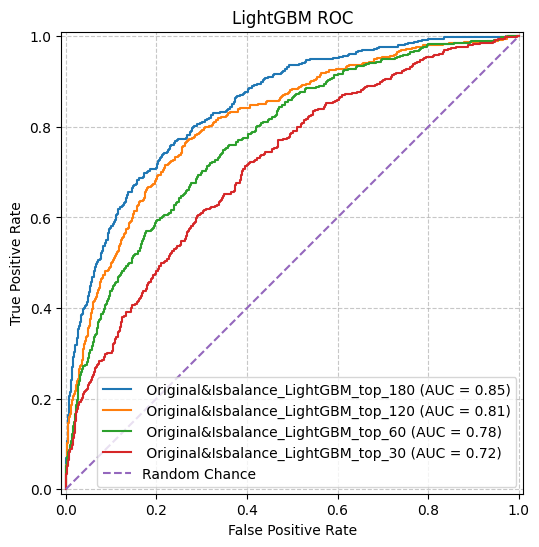

In [5]:
#ORIGINAL & IS_UNBALANCE
mi = mutual_info_classif(X_train_0, y_train_0, random_state=random_seed)
feat_scores_0 = pd.DataFrame({'feature': X_train_0.columns, 'mi': mi}).sort_values('mi', ascending=False).reset_index(drop=True)
feature_sets = {f"Original&Isbalance_LightGBM_top_{k}": feat_scores_0['feature'].iloc[:k].tolist() for k in k_list}

fig, ax = plt.subplots(figsize=(6, 6))

best_model_0 = None
best_auc_0 = -1

for name, feats in feature_sets.items():
    start_time = time.perf_counter()
    print(f"\n=== LightGBM: {name} ({len(feats)} features) ===")

    X_train_sub_0 = X_train_0[feats]
    X_test_sub_0 = X_test[feats]

    lgbm_0 = LGBMClassifier(
        n_estimators=200,
        is_unbalance=True,  
        random_state=random_seed,
        n_jobs=-1
    )
    lgbm_0.fit(X_train_sub_0, y_train_0)

    y_prob_0 = lgbm_0.predict_proba(X_test_sub_0)[:,1]
    y_pred_0 = lgbm_0.predict(X_test_sub_0)
    
    end_time = time.perf_counter()
    duration = end_time - start_time

    print("AUC:", roc_auc_score(y_test, y_prob_0))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_0))
    print("Classification Report:\n", classification_report(y_test, y_pred_0, zero_division=0))
    print(f"Loop finished in {duration:.4f} seconds")

    if roc_auc_score(y_test, y_prob_0) > best_auc_0:
        best_auc_0 = roc_auc_score(y_test, y_prob_0)
        best_model_0 = {'name':name, 'features': len(feats), 'auc': roc_auc_score(y_test, y_prob_0), 
                      'Accuracy': accuracy_score(y_test, y_pred_0),
                      'Precision': precision_score(y_test, y_pred_0, zero_division=0),
                      'Recall': recall_score(y_test, y_pred_0, zero_division=0),
                      'F1-score': f1_score(y_test, y_pred_0, zero_division=0),
                      'y_pred': y_pred_0, 'y_prob': y_prob_0, 'Training time':round(duration,2)}

    RocCurveDisplay.from_predictions(y_test, y_prob_0, name=f" {name}", ax=ax)

ax.plot([0, 1], [0, 1], "--", label="Random Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("LightGBM ROC")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [6]:
#Training set 1: SMOTE to 0.43 (30:70 ratio) & then RUS to 0.67 (40:60 ratio)
target_over = 0.43
smote=SMOTE(sampling_strategy=target_over, random_state=random_seed) 
X_smote, y_smote = smote.fit_resample(X_train,y_train) 
print("--- Before SMOTE Oversampling ---")
print(y_train.value_counts()) 
print("--- After SMOTE Oversampling ---") 
print(y_smote.value_counts())
target_final_1 = 0.67
rus = RandomUnderSampler(sampling_strategy=target_final_1, random_state=random_seed)
X_train_1, y_train_1 = rus.fit_resample(X_smote, y_smote)
print("--- After Undersampling ---")  
print(y_train_1.value_counts())

--- Before SMOTE Oversampling ---
target
0    14429
1     1571
Name: count, dtype: int64
--- After SMOTE Oversampling ---
target
0    14429
1     6204
Name: count, dtype: int64
--- After Undersampling ---
target
0    9259
1    6204
Name: count, dtype: int64



=== LightGBM: SMOTE&RUS_LGBM_top_180 (180 features) ===
AUC: 0.7601779406878484
[is_unbalance] Confusion Matrix:
[[3445  162]
 [ 303   90]]
[is_unbalance] Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      3607
           1       0.36      0.23      0.28       393

    accuracy                           0.88      4000
   macro avg       0.64      0.59      0.61      4000
weighted avg       0.86      0.88      0.87      4000



c:\Users\Doan Giang Co\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


AUC: 0.7370662501737151
[scale_pos_weight] Confusion Matrix:
[[3083  524]
 [ 219  174]]
[scale_pos_weight] Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89      3607
           1       0.25      0.44      0.32       393

    accuracy                           0.81      4000
   macro avg       0.59      0.65      0.61      4000
weighted avg       0.87      0.81      0.84      4000


=== LightGBM: SMOTE&RUS_LGBM_top_120 (120 features) ===


c:\Users\Doan Giang Co\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


AUC: 0.7293077991550215
[is_unbalance] Confusion Matrix:
[[3379  228]
 [ 293  100]]
[is_unbalance] Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      3607
           1       0.30      0.25      0.28       393

    accuracy                           0.87      4000
   macro avg       0.61      0.60      0.60      4000
weighted avg       0.86      0.87      0.86      4000



...

c:\Users\Doan Giang Co\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


AUC: 0.6055288310614574
[is_unbalance] Confusion Matrix:
[[3075  532]
 [ 302   91]]
[is_unbalance] Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      3607
           1       0.15      0.23      0.18       393

    accuracy                           0.79      4000
   macro avg       0.53      0.54      0.53      4000
weighted avg       0.84      0.79      0.81      4000



c:\Users\Doan Giang Co\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


AUC: 0.5934530750569116
[scale_pos_weight] Confusion Matrix:
[[2255 1352]
 [ 186  207]]
[scale_pos_weight] Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.63      0.75      3607
           1       0.13      0.53      0.21       393

    accuracy                           0.62      4000
   macro avg       0.53      0.58      0.48      4000
weighted avg       0.85      0.62      0.69      4000



c:\Users\Doan Giang Co\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


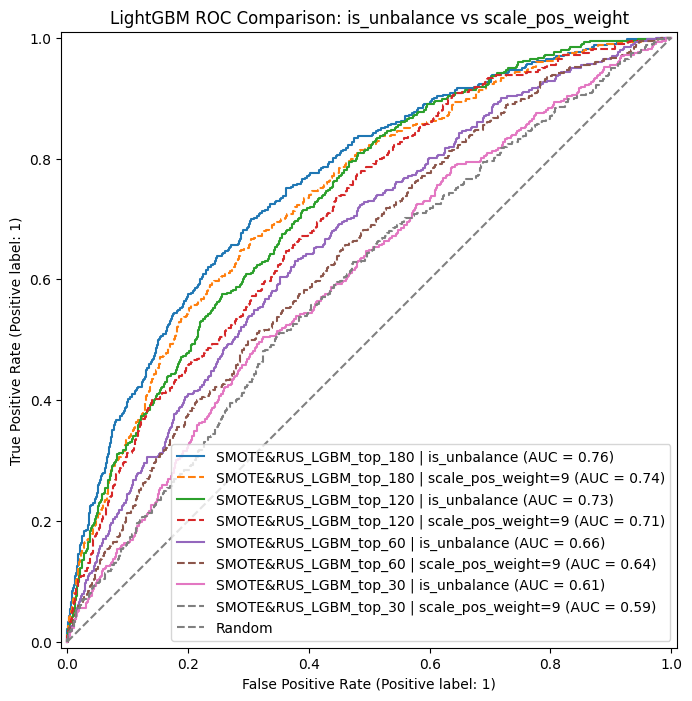

In [7]:
#SMOTE&RUS with IS_UNBALANCE & POS_SCALE_WEIGHT 
mi_1 = mutual_info_classif(X_train_1, y_train_1, random_state=random_seed)
feat_scores_1 = pd.DataFrame({'feature': X_train_1.columns, 'mi': mi_1}) \
                .sort_values('mi', ascending=False).reset_index(drop=True)

feature_sets_1 = {f"SMOTE&RUS_LGBM_top_{k}": feat_scores_1['feature'].iloc[:k].tolist() for k in k_list}
best_model_1_A = None
best_auc_1_A = -1

best_model_1_B = None
best_auc_1_B = -1

fig, ax = plt.subplots(figsize=(8,8))

for name, feats in feature_sets_1.items():
    start_time_A = time.perf_counter()
    print(f"\n=== LightGBM: {name} ({len(feats)} features) ===")
    
    X_train_sub = X_train_1[feats]
    X_test_sub = X_test[feats]
    # ---------------------------------------------------------
    #  MODEL A — is_unbalance=True
    # ---------------------------------------------------------
    lgbm1_A = LGBMClassifier(
        n_estimators=200,
        is_unbalance=True,
        random_state=random_seed,
        n_jobs=-1,
        verbosity=-1,
        force_col_wise=True
    )
    lgbm1_A.fit(X_train_sub, y_train_1)

    y_prob_A = lgbm1_A.predict_proba(X_test_sub)[:,1]
    y_pred_A = lgbm1_A.predict(X_test_sub)

    end_time_A = time.perf_counter()
    duration_A = end_time_A - start_time_A

    print("AUC:", roc_auc_score(y_test, y_prob_A))
    print("[is_unbalance] Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_A))
    print("[is_unbalance] Classification Report:")
    print(classification_report(y_test, y_pred_A, zero_division=0))

    if roc_auc_score(y_test, y_prob_A) > best_auc_1_A:
        best_auc_1_A = roc_auc_score(y_test, y_prob_A)
        best_model_1_A = {'name': name , 'features': len(feats),'auc': roc_auc_score(y_test, y_prob_A), 
                      'Accuracy': accuracy_score(y_test, y_pred_A),
                      'Precision': precision_score(y_test, y_pred_A, zero_division=0),
                      'Recall': recall_score(y_test, y_pred_A, zero_division=0),
                      'F1-score': f1_score(y_test, y_pred_A, zero_division=0),
                      'y_pred': y_pred_A, 'y_prob': y_prob_A, 'Training time':round(duration_A,2)} 

    RocCurveDisplay.from_predictions(y_test, y_prob_A,name=f"{name} | is_unbalance",ax=ax,linestyle='solid')
    # ---------------------------------------------------------
    #  MODEL B — scale_pos_weight=9
    # ---------------------------------------------------------
    start_time_B = time.perf_counter()
    lgbm1_B = LGBMClassifier(
        n_estimators=200,
        scale_pos_weight=9,
        random_state=random_seed,
        n_jobs=-1,
        verbosity=-1,
        force_col_wise=True
    )
    lgbm1_B.fit(X_train_sub, y_train_1)

    y_prob_B = lgbm1_B.predict_proba(X_test_sub)[:,1]
    y_pred_B = lgbm1_B.predict(X_test_sub)

    end_time_B = time.perf_counter()
    duration_B = end_time_B - start_time_B

    print("AUC:", roc_auc_score(y_test, y_prob_B))
    print("[scale_pos_weight] Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_B))
    print("[scale_pos_weight] Classification Report:")
    print(classification_report(y_test, y_pred_B, zero_division=0))

    if roc_auc_score(y_test, y_prob_B) > best_auc_1_B:
        best_auc_1_B = roc_auc_score(y_test, y_prob_B)
        best_model_1_B = {'name': name , 'features': len(feats),'auc': roc_auc_score(y_test, y_prob_B), 
                      'Accuracy': accuracy_score(y_test, y_pred_B),
                      'Precision': precision_score(y_test, y_pred_B, zero_division=0),
                      'Recall': recall_score(y_test, y_pred_B, zero_division=0),
                      'F1-score': f1_score(y_test, y_pred_B, zero_division=0),
                      'y_pred': y_pred_B, 'y_prob': y_prob_B, 'Training time':round(duration_A,2)} 

    RocCurveDisplay.from_predictions(y_test, y_prob_B, name=f"{name} | scale_pos_weight=9", ax=ax, linestyle='--')

ax.plot([0,1], [0,1], '--', color='gray', label='Random')
ax.legend(loc="lower right")
ax.set_title("LightGBM ROC Comparison: is_unbalance vs scale_pos_weight")
plt.show()


In [8]:
#Training set 2: RUS to minority/majority ratio = 0.18 (15:85 ratio)
target_final_2 = 0.18
rus_2 = RandomUnderSampler(sampling_strategy=target_final_2, random_state=random_seed)
X_train_2, y_train_2 = rus_2.fit_resample(X_train,y_train) 
print("--- Before Undersampling ---") 
print(y_train.value_counts()) 
print("--- After Undersampling ---") 
print(y_train_2.value_counts())

--- Before Undersampling ---
target
0    14429
1     1571
Name: count, dtype: int64
--- After Undersampling ---
target
0    8727
1    1571
Name: count, dtype: int64



=== LightGBM: RUS_LGBM_top_180 (180 features) ===
AUC: 0.8509048351699515
[is_unbalance] Confusion Matrix:
[[3484  123]
 [ 238  155]]
[is_unbalance] Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      3607
           1       0.56      0.39      0.46       393

    accuracy                           0.91      4000
   macro avg       0.75      0.68      0.71      4000
weighted avg       0.90      0.91      0.90      4000



c:\Users\Doan Giang Co\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


AUC: 0.8437742275233836
[scale_pos_weight] Confusion Matrix:
[[3427  180]
 [ 224  169]]
[scale_pos_weight] Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      3607
           1       0.48      0.43      0.46       393

    accuracy                           0.90      4000
   macro avg       0.71      0.69      0.70      4000
weighted avg       0.89      0.90      0.90      4000


=== LightGBM: RUS_LGBM_top_120 (120 features) ===


c:\Users\Doan Giang Co\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


AUC: 0.83103253427919
[is_unbalance] Confusion Matrix:
[[3433  174]
 [ 246  147]]
[is_unbalance] Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      3607
           1       0.46      0.37      0.41       393

    accuracy                           0.90      4000
   macro avg       0.70      0.66      0.68      4000
weighted avg       0.89      0.90      0.89      4000



...

c:\Users\Doan Giang Co\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


AUC: 0.6811536233969713
[is_unbalance] Confusion Matrix:
[[3222  385]
 [ 275  118]]
[is_unbalance] Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      3607
           1       0.23      0.30      0.26       393

    accuracy                           0.83      4000
   macro avg       0.58      0.60      0.59      4000
weighted avg       0.85      0.83      0.84      4000



c:\Users\Doan Giang Co\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


AUC: 0.6642060850015273
[scale_pos_weight] Confusion Matrix:
[[3007  600]
 [ 253  140]]
[scale_pos_weight] Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.83      0.88      3607
           1       0.19      0.36      0.25       393

    accuracy                           0.79      4000
   macro avg       0.56      0.59      0.56      4000
weighted avg       0.85      0.79      0.81      4000



c:\Users\Doan Giang Co\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


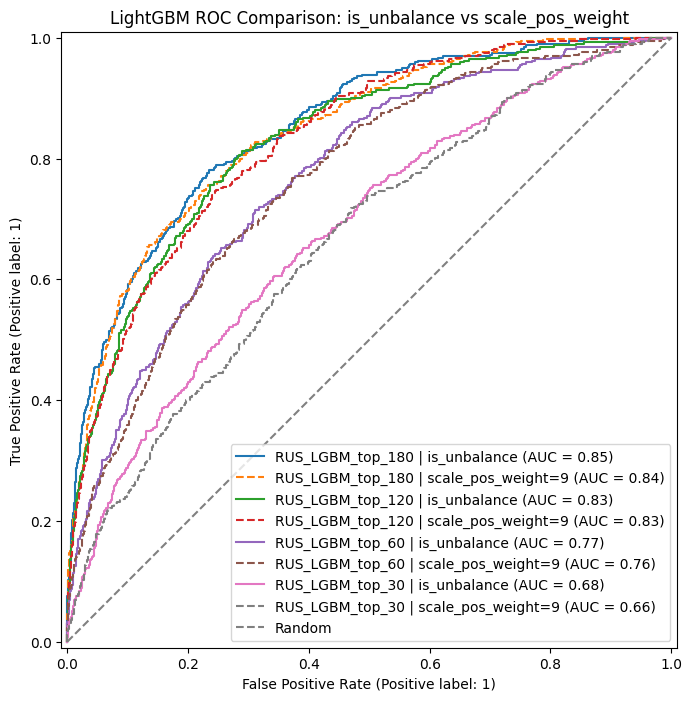

In [9]:
#SMOTE&RUS with IS_UNBALANCE & POS_SCALE_WEIGHT 
mi_2 = mutual_info_classif(X_train_2, y_train_2, random_state=random_seed)
feat_scores_2 = pd.DataFrame({'feature': X_train_2.columns, 'mi': mi_2}).sort_values('mi', ascending=False).reset_index(drop=True)

feature_sets_2 = {f"RUS_LGBM_top_{k}": feat_scores_2['feature'].iloc[:k].tolist() for k in k_list}
best_model_2_A = None
best_auc_2_A = -1

best_model_2_B = None
best_auc_2_B = -1

fig, ax = plt.subplots(figsize=(8,8))

for name, feats in feature_sets_2.items():
    start_time_A = time.perf_counter()
    print(f"\n=== LightGBM: {name} ({len(feats)} features) ===")
    
    X_train_sub = X_train_2[feats]
    X_test_sub = X_test[feats]
    # ---------------------------------------------------------
    #  MODEL A — is_unbalance=True
    # ---------------------------------------------------------
    lgbm1_A = LGBMClassifier(
        n_estimators=200,
        is_unbalance=True,
        random_state=random_seed,
        n_jobs=-1,
        verbosity=-1,
        force_col_wise=True
    )
    lgbm1_A.fit(X_train_sub, y_train_2)

    y_prob_A = lgbm1_A.predict_proba(X_test_sub)[:,1]
    y_pred_A = lgbm1_A.predict(X_test_sub)

    end_time_A = time.perf_counter()
    duration_A = end_time_A - start_time_A

    print("AUC:", roc_auc_score(y_test, y_prob_A))
    print("[is_unbalance] Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_A))
    print("[is_unbalance] Classification Report:")
    print(classification_report(y_test, y_pred_A, zero_division=0))

    if roc_auc_score(y_test, y_prob_A) > best_auc_2_A:
        best_auc_2_A = roc_auc_score(y_test, y_prob_A)
        best_model_2_A = {'name': name , 'features': len(feats),'auc': roc_auc_score(y_test, y_prob_A), 
                      'Accuracy': accuracy_score(y_test, y_pred_A),
                      'Precision': precision_score(y_test, y_pred_A, zero_division=0),
                      'Recall': recall_score(y_test, y_pred_A, zero_division=0),
                      'F1-score': f1_score(y_test, y_pred_A, zero_division=0),
                      'y_pred': y_pred_A, 'y_prob': y_prob_A, 'Training time':round(duration_A,2)} 

    RocCurveDisplay.from_predictions(y_test, y_prob_A,name=f"{name} | is_unbalance",ax=ax,linestyle='solid')
    # ---------------------------------------------------------
    #  MODEL B — scale_pos_weight=9
    # ---------------------------------------------------------
    start_time_B = time.perf_counter()
    lgbm1_B = LGBMClassifier(
        n_estimators=200,
        scale_pos_weight=9,
        random_state=random_seed,
        n_jobs=-1,
        verbosity=-1,
        force_col_wise=True
    )
    lgbm1_B.fit(X_train_sub, y_train_2)

    y_prob_B = lgbm1_B.predict_proba(X_test_sub)[:,1]
    y_pred_B = lgbm1_B.predict(X_test_sub)

    end_time_B = time.perf_counter()
    duration_B = end_time_B - start_time_B

    print("AUC:", roc_auc_score(y_test, y_prob_B))
    print("[scale_pos_weight] Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_B))
    print("[scale_pos_weight] Classification Report:")
    print(classification_report(y_test, y_pred_B, zero_division=0))

    if roc_auc_score(y_test, y_prob_B) > best_auc_2_B:
        best_auc_2_B = roc_auc_score(y_test, y_prob_B)
        best_model_2_B = {'name': name , 'features': len(feats),'auc': roc_auc_score(y_test, y_prob_B), 
                      'Accuracy': accuracy_score(y_test, y_pred_B),
                      'Precision': precision_score(y_test, y_pred_B, zero_division=0),
                      'Recall': recall_score(y_test, y_pred_B, zero_division=0),
                      'F1-score': f1_score(y_test, y_pred_B, zero_division=0),
                      'y_pred': y_pred_B, 'y_prob': y_prob_B, 'Training time':round(duration_A,2)} 

    RocCurveDisplay.from_predictions(y_test, y_prob_B, name=f"{name} | scale_pos_weight=9", ax=ax, linestyle='--')

ax.plot([0,1], [0,1], '--', color='gray', label='Random')
ax.legend(loc="lower right")
ax.set_title("LightGBM ROC Comparison: is_unbalance vs scale_pos_weight")
plt.show()


In [14]:
all_models = [best_model_0, best_model_1_A, best_model_1_B, best_model_2_A, best_model_2_B]
comparision = pd.DataFrame(all_models)
comparision = comparision[['name', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'auc','Training time']]
comparision.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC','Training time']
print("="*100)
print("MODEL PERFORMANCE COMPARISON")
print("="*100)
print(comparision.to_string(index=False))
print("="*100)
# Identify the best model for each metric
print("Best Models by Metric:")
print(f"Highest Accuracy:  {comparision.loc[comparision['Accuracy'].idxmax(), 'Model']} ({comparision['Accuracy'].max():.4f})")
print(f"Highest Precision: {comparision.loc[comparision['Precision'].idxmax(), 'Model']} ({comparision['Precision'].max():.4f})")
print(f"Highest Recall:    {comparision.loc[comparision['Recall'].idxmax(), 'Model']} ({comparision['Recall'].max():.4f})")
print(f"Highest F1-Score:  {comparision.loc[comparision['F1-Score'].idxmax(), 'Model']} ({comparision['F1-Score'].max():.4f})")
print(f"Highest AUC:       {comparision.loc[comparision['AUC'].idxmax(), 'Model']} ({comparision['AUC'].max():.4f})")
print("="*100)

MODEL PERFORMANCE COMPARISON
                              Model  Accuracy  Precision   Recall  F1-Score      AUC  Training time
Original&Isbalance_LightGBM_top_180   0.91175   0.595238 0.318066  0.414594 0.847390          56.67
             SMOTE&RUS_LGBM_top_180   0.88375   0.357143 0.229008  0.279070 0.760178          35.47
             SMOTE&RUS_LGBM_top_180   0.81425   0.249284 0.442748  0.318973 0.737066          35.47
                   RUS_LGBM_top_180   0.90975   0.557554 0.394402  0.461997 0.850905          32.46
                   RUS_LGBM_top_180   0.89900   0.484241 0.430025  0.455526 0.843774          32.46
Best Models by Metric:
Highest Accuracy:  Original&Isbalance_LightGBM_top_180 (0.9117)
Highest Precision: Original&Isbalance_LightGBM_top_180 (0.5952)
Highest Recall:    SMOTE&RUS_LGBM_top_180 (0.4427)
Highest F1-Score:  RUS_LGBM_top_180 (0.4620)
Highest AUC:       RUS_LGBM_top_180 (0.8509)


---

## Summary

In this notebook, we have:
1. Continued as tested algothirms part of the overall project, inheriting decisions from the previous data engineering phase.
2. Built and evaluated a **LightGBM** model using a small sample of the dataset.
3. Applied three different data balancing methods:
4. Visualized model performance using ROC Curve and calculated AUC values.
    - Original (Unbalanced)
    - SMOTE & RUS
    - RUS
5. Compared all models across multiple metrics (accuracy, precision, recall, F1-score, AUC).

**Key findings**:
The best-performing model for further comparison:  RUS and 180-variable threshold with LightGBM is_unbalance (RUS_LGBM_top_180)